In [2]:
import pandas as pd

In [3]:
import os
os.getcwd()

'c:\\Claresta\\Claresta UB\\SEMESTER 4\\REKAYASA DATA DAN VISUALISASI\\TAXI\\repositories\\nyc-taxi\\src\\nyc_taxi\\pipeline\\step_02_preprocessing\\preprocessing'

In [4]:
yellow_01 = pd.read_parquet('../../../../../data/bronze/yellow_tripdata_2025-01.parquet')
yellow_02 = pd.read_parquet('../../../../../data/bronze/yellow_tripdata_2025-02.parquet')
yellow_03 = pd.read_parquet('../../../../../data/bronze/yellow_tripdata_2025-03.parquet')
yellow_04 = pd.read_parquet('../../../../../data/bronze/yellow_tripdata_2025-04.parquet')
yellow_01.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [4]:
yellow_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [ ]:
drop_cols_yellow = [
    "VendorID",              # ID vendor taksi, tidak relevan
    "RatecodeID",            # kode tarif, tidak dianalisis
    "store_and_fwd_flag",    # flag koneksi GPS, tidak relevan
    "payment_type",          # tunai/kartu, tidak dianalisis
    "extra",                 # surcharge tambahan, sudah tercakup total_amount
    "mta_tax",               # pajak MTA, tidak dianalisis
    "tolls_amount",          # tol, tidak dianalisis
    "improvement_surcharge", # surcharge, tidak dianalisis
    "congestion_surcharge",  # biaya kemacetan, tidak dianalisis
    "Airport_fee",           # biaya bandara, tidak dianalisis
    "cbd_congestion_fee",    # biaya central business district, tidak dianalisis
]

In [6]:
yellow_01.drop(columns=drop_cols_yellow, axis=1, inplace=True)
yellow_02.drop(columns=drop_cols_yellow, axis=1, inplace=True)
yellow_03.drop(columns=drop_cols_yellow, axis=1, inplace=True)
yellow_04.drop(columns=drop_cols_yellow, axis=1, inplace=True)

In [7]:
yellow_01.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,tip_amount,total_amount
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,229,237,10.0,3.00,18.00
1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,236,237,5.1,2.02,12.12
2,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,141,141,5.1,2.00,12.10
3,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,244,244,7.2,0.00,9.70
4,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,244,116,5.8,0.00,8.30


In [8]:
yellow_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 9 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int32         
 5   DOLocationID           int32         
 6   fare_amount            float64       
 7   tip_amount             float64       
 8   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int32(2)
memory usage: 212.1 MB


In [5]:
green_01 = pd.read_parquet('../../../../../data/bronze/green_tripdata_2025-01.parquet')
green_02 = pd.read_parquet('../../../../../data/bronze/green_tripdata_2025-02.parquet')
green_03 = pd.read_parquet('../../../../../data/bronze/green_tripdata_2025-03.parquet')
green_04 = pd.read_parquet('../../../../../data/bronze/green_tripdata_2025-04.parquet')
green_01.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2025-01-01 00:03:01,2025-01-01 00:17:12,N,1.0,75,235,1.0,5.93,24.70,...,0.5,6.80,0.00,NaN,1.0,34.00,1.0,1.0,0.00,0.0
1,2,2025-01-01 00:19:59,2025-01-01 00:25:52,N,1.0,166,75,1.0,1.32,8.60,...,0.5,0.00,0.00,NaN,1.0,11.10,2.0,1.0,0.00,0.0
2,2,2025-01-01 00:05:29,2025-01-01 00:07:21,N,5.0,171,73,1.0,0.41,25.55,...,0.0,0.00,0.00,NaN,1.0,26.55,2.0,2.0,0.00,0.0
3,2,2025-01-01 00:52:24,2025-01-01 01:07:52,N,1.0,74,223,1.0,4.12,21.20,...,0.5,6.13,6.94,NaN,1.0,36.77,1.0,1.0,0.00,0.0
4,2,2025-01-01 00:25:05,2025-01-01 01:01:10,N,1.0,66,158,1.0,4.71,33.80,...,0.5,7.81,0.00,NaN,1.0,46.86,1.0,1.0,2.75,0.0


In [10]:
green_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48326 entries, 0 to 48325
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               48326 non-null  int32         
 1   lpep_pickup_datetime   48326 non-null  datetime64[us]
 2   lpep_dropoff_datetime  48326 non-null  datetime64[us]
 3   store_and_fwd_flag     46490 non-null  object        
 4   RatecodeID             46490 non-null  float64       
 5   PULocationID           48326 non-null  int32         
 6   DOLocationID           48326 non-null  int32         
 7   passenger_count        46490 non-null  float64       
 8   trip_distance          48326 non-null  float64       
 9   fare_amount            48326 non-null  float64       
 10  extra                  48326 non-null  float64       
 11  mta_tax                48326 non-null  float64       
 12  tip_amount             48326 non-null  float64       
 13  t

In [11]:
drop_cols_green = [
    "VendorID",              # ID vendor, tidak relevan
    "store_and_fwd_flag",    # flag GPS, tidak relevan
    "RatecodeID",            # kode tarif, tidak dianalisis
    "payment_type",          # tunai/kartu, tidak dianalisis
    "trip_type",             # street-hail vs dispatch, tidak dianalisis
    "extra",                 # surcharge tambahan, tidak dianalisis
    "mta_tax",               # pajak MTA, tidak dianalisis
    "tolls_amount",          # tol, tidak dianalisis
    "improvement_surcharge", # surcharge, tidak dianalisis
    "congestion_surcharge",  # biaya kemacetan, tidak dianalisis
    "cbd_congestion_fee",    # biaya central business district, tidak dianalisis
    "ehail_fee",             # semua null, tidak ada nilainya sama sekali
]

In [12]:
green_01.drop(columns=drop_cols_green, axis=1, inplace=True)
green_02.drop(columns=drop_cols_green, axis=1, inplace=True)
green_03.drop(columns=drop_cols_green, axis=1, inplace=True)
green_04.drop(columns=drop_cols_green, axis=1, inplace=True)

In [13]:
green_04.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52132 entries, 0 to 52131
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   lpep_pickup_datetime   52132 non-null  datetime64[us]
 1   lpep_dropoff_datetime  52132 non-null  datetime64[us]
 2   PULocationID           52132 non-null  int32         
 3   DOLocationID           52132 non-null  int32         
 4   passenger_count        48944 non-null  float64       
 5   trip_distance          52132 non-null  float64       
 6   fare_amount            52132 non-null  float64       
 7   tip_amount             52132 non-null  float64       
 8   total_amount           52132 non-null  float64       
dtypes: datetime64[us](2), float64(5), int32(2)
memory usage: 3.2 MB


In [14]:
# ubah nama kolom menjadi lowercase pada yellow taxi
for df in [yellow_01, yellow_02, yellow_03, yellow_04]:
    df.columns = df.columns.str.lower()
yellow_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 9 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   pulocationid           int32         
 5   dolocationid           int32         
 6   fare_amount            float64       
 7   tip_amount             float64       
 8   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int32(2)
memory usage: 212.1 MB


In [15]:
# lowercase untuk green taxi
for df in [green_01, green_02, green_03, green_04]:
    df.columns = df.columns.str.lower()
green_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48326 entries, 0 to 48325
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   lpep_pickup_datetime   48326 non-null  datetime64[us]
 1   lpep_dropoff_datetime  48326 non-null  datetime64[us]
 2   pulocationid           48326 non-null  int32         
 3   dolocationid           48326 non-null  int32         
 4   passenger_count        46490 non-null  float64       
 5   trip_distance          48326 non-null  float64       
 6   fare_amount            48326 non-null  float64       
 7   tip_amount             48326 non-null  float64       
 8   total_amount           48326 non-null  float64       
dtypes: datetime64[us](2), float64(5), int32(2)
memory usage: 2.9 MB


In [16]:
yellow_01.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,tip_amount,total_amount
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,229,237,10.0,3.00,18.00
1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,236,237,5.1,2.02,12.12
2,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,141,141,5.1,2.00,12.10
3,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,244,244,7.2,0.00,9.70
4,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,244,116,5.8,0.00,8.30


# THRESHOLD

In [54]:
LOWER_FARE_YELLOW = 2.50
UPPER_FARE_YELLOW = 300
LOWER_TOTAL_AMOUNT_YELLOW = 3.00
UPPER_TOTAL_AMOUNT_YELLOW = 350
LOWER_TIP_AMOUNT_YELLOW = 0
UPPER_TIP_AMOUNT_YELLOW = 200
LOWER_TRIP_DISTANCE_YELLOW = 0.1
UPPER_TRIP_DISTANCE_YELLOW = 100
LOWER_TRIP_DURATION_MIN_YELLOW = 1
UPPER_TRIP_DURATION_MIN_YELLOW = 180

LOWER_FARE_GREEN = 2.50
UPPER_FARE_GREEN = 200
LOWER_TOTAL_AMOUNT_GREEN = 3.00
UPPER_TOTAL_AMOUNT_GREEN = 250
LOWER_TIP_AMOUNT_GREEN = 0
UPPER_TIP_AMOUNT_GREEN = 150
LOWER_TRIP_DISTANCE_GREEN = 0.1
UPPER_TRIP_DISTANCE_GREEN = 60
LOWER_TRIP_DURATION_MIN_GREEN = 1
UPPER_TRIP_DURATION_MIN_GREEN = 120

# Add trip_duration_min on Yellow and Green Taxi Table

In [ ]:
# penambahan kolom trip_duration_min pada dataframe yellow dan green taxi
for df in [yellow_01, yellow_02, yellow_03, yellow_04]:
    df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Yellow Taxi January 2025 Data Cleaning

In [17]:
yellow_01.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,tip_amount,total_amount
count,3475226,3475226,2.935077e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06
mean,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,1.651916e+02,1.641252e+02,1.708180e+01,2.959813e+00,2.561129e+01
min,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+02,-8.600000e+01,-9.010000e+02
25%,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.320000e+02,1.130000e+02,8.600000e+00,0.000000e+00,1.520000e+01
50%,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.620000e+02,1.620000e+02,1.211000e+01,2.450000e+00,1.995000e+01
75%,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,2.340000e+02,2.340000e+02,1.950000e+01,3.930000e+00,2.778000e+01
max,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,2.650000e+02,2.650000e+02,8.633721e+05,4.000000e+02,8.633804e+05
std,NaN,NaN,7.507503e-01,5.646016e+02,6.452948e+01,6.940169e+01,4.634729e+02,3.779681e+00,4.636585e+02


In [ ]:
k1_y1 = yellow_01['passenger_count'] == 0
k2_y1 = yellow_01['passenger_count'].isna()
k3_y1 = yellow_01['trip_distance'] < LOWER_TRIP_DISTANCE_YELLOW
k4_y1 = yellow_01['trip_distance'] > UPPER_TRIP_DISTANCE_YELLOW
k5_y1 = yellow_01['trip_distance'].isna()
k6_y1 = yellow_01['fare_amount'] < LOWER_FARE_YELLOW
k7_y1 = yellow_01['fare_amount'] > UPPER_FARE_YELLOW
k8_y1 = yellow_01['fare_amount'].isna()     # Harga di atas 1000 USD
k9_y1 = yellow_01['total_amount'] < LOWER_TOTAL_AMOUNT_YELLOW
k10_y1 = yellow_01['total_amount'] > UPPER_TOTAL_AMOUNT_YELLOW
k11_y1 = yellow_01['total_amount'].isna()
k12_y1 = yellow_01['tip_amount'] < LOWER_TIP_AMOUNT_YELLOW
k13_y1 = yellow_01['tip_amount'] > UPPER_TIP_AMOUNT_YELLOW
k14_y1 = yellow_01['tip_amount'].isna()
k12_y1 = yellow_01['trip_duration_min'] < LOWER_TRIP_DURATION_MIN_YELLOW
k13_y1 = yellow_01['trip_duration_min'] > UPPER_TRIP_DURATION_MIN_YELLOW
k14_y1 = yellow_01['trip_duration_min'].isna()

print(yellow_01[k1_y1].shape[0])
print(yellow_01[k2_y1].shape[0])
print(yellow_01[k3_y1].shape[0])
print(yellow_01[k4_y1].shape[0])
print(yellow_01[k5_y1].shape[0])
print(yellow_01[k6_y1].shape[0])
print(yellow_01[k7_y1].shape[0])
print(yellow_01[k8_y1].shape[0])
print(yellow_01[k9_y1].shape[0])
print(yellow_01[k10_y1].shape[0])
print(yellow_01[k11_y1].shape[0])
print(yellow_01[k12_y1].shape[0])
print(yellow_01[k13_y1].shape[0])
print(yellow_01[k14_y1].shape[0])

24656
540149
112621
162
0
148270
327
0
87718
318
0
124
10
0
112621
162
0


In [ ]:
print(f"Total awal: {yellow_01.shape[0]:,} baris")

# Isi null passenger_count dengan median
median_pax_y1 = yellow_01['passenger_count'].median()
yellow_01['passenger_count'] = yellow_01['passenger_count'].fillna(median_pax_y1)
print(f"passenger_count null diisi median: {median_pax_y1}")

# AMBIL DATA BERSIH
kondisi_hapus = (
    (yellow_01['passenger_count'] > 0) &
    (yellow_01['fare_amount'].between(LOWER_FARE_YELLOW, UPPER_FARE_YELLOW)) &
    (yellow_01['total_amount'].between(LOWER_TOTAL_AMOUNT_YELLOW, UPPER_TOTAL_AMOUNT_YELLOW)) &
    (yellow_01['tip_amount'].between(LOWER_TIP_AMOUNT_YELLOW, UPPER_TIP_AMOUNT_YELLOW)) &
    (yellow_01['trip_distance'].between(LOWER_TRIP_DISTANCE_YELLOW, UPPER_TRIP_DISTANCE_YELLOW)) &
    (yellow_01['trip_duration_min'].between(LOWER_TRIP_DURATION_MIN_YELLOW, UPPER_TRIP_DURATION_MIN_YELLOW))
)
yellow_01_clean = yellow_01[kondisi_hapus].copy()
print(f"Setelah hapus anomali: {yellow_01_clean.shape[0]:,} baris")
print(f"Dihapus: {yellow_01.shape[0] - yellow_01_clean.shape[0]:,} baris")

Total awal: 3,475,226 baris
Setelah hapus anomali: 3,230,659 baris
Dihapus: 244,567 baris
passenger_count null diisi median: 1.0


In [21]:
yellow_01_clean.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pulocationid             0
dolocationid             0
fare_amount              0
tip_amount               0
total_amount             0
dtype: int64

# Yellow Taxi February 2025 Data Cleaning

In [22]:
yellow_02.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,tip_amount,total_amount
count,3577543,3577543,2.770606e+06,3.577543e+06,3.577543e+06,3.577543e+06,3.577543e+06,3.577543e+06,3.577543e+06
mean,2025-02-15 03:32:25.140901,2025-02-15 03:47:49.613170,1.276028e+00,6.025357e+00,1.632846e+02,1.624813e+02,1.674901e+01,2.730064e+00,2.503055e+01
min,2025-01-31 22:22:53,2025-01-31 22:30:00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-1.807600e+03,-2.200000e+02,-1.832850e+03
25%,2025-02-08 01:18:52,2025-02-08 01:31:19,1.000000e+00,1.000000e+00,1.250000e+02,1.130000e+02,8.600000e+00,0.000000e+00,1.531000e+01
50%,2025-02-14 21:06:49,2025-02-14 21:23:14,1.000000e+00,1.700000e+00,1.610000e+02,1.620000e+02,1.280000e+01,2.110000e+00,2.019000e+01
75%,2025-02-21 23:07:40.500000,2025-02-21 23:21:48.500000,1.000000e+00,3.180000e+00,2.330000e+02,2.340000e+02,1.980000e+01,3.790000e+00,2.797000e+01
max,2025-03-01 00:06:32,2025-03-01 23:13:42,9.000000e+00,2.287825e+05,2.650000e+02,2.650000e+02,1.325314e+05,4.400000e+02,1.325554e+05
std,NaN,NaN,7.223483e-01,5.433970e+02,6.562958e+01,6.986419e+01,7.212927e+01,3.652688e+00,7.318542e+01


In [23]:
k1_y2 = yellow_02['passenger_count'] == 0.0
k2_y2 = yellow_02['passenger_count'].isna()
k3_y2 = yellow_02['trip_distance'] == 0.0
k4_y2 = yellow_02['trip_distance'].isna()
k5_y2 = yellow_02['fare_amount'] < 0.0
k6_y2 = yellow_02['total_amount'] < 0.0
k7_y2 = yellow_02['trip_distance'] > 100.0     # Jarak lebih dari 100 mil
k8_y2 = yellow_02['passenger_count'] > 6.0    # Penumpang lebih dari 6 (kapasitas maks SUV)
k9_y2 = yellow_02['fare_amount'] > 1000.0     # Harga di atas 1000 USD

print(yellow_02[k1_y2].shape[0])
print(yellow_02[k2_y2].shape[0])
print(yellow_02[k3_y2].shape[0])
print(yellow_02[k4_y2].shape[0])
print(yellow_02[k5_y2].shape[0])
print(yellow_02[k6_y2].shape[0])
print(yellow_02[k7_y2].shape[0])
print(yellow_02[k8_y2].shape[0])
print(yellow_02[k9_y2].shape[0])

21751
806937
99771
0
182655
55179
172
16
6


In [24]:
print(f"Total awal: {yellow_02.shape[0]:,} baris")

# Hapus anomali yang jelas tidak valid
kondisi_hapus = (k1_y2 | k3_y2 | k5_y2 | k6_y2 | k7_y2 | k8_y1 | k9_y2)
yellow_02_clean = yellow_02[~kondisi_hapus].copy()
print(f"Setelah hapus anomali: {yellow_02_clean.shape[0]:,} baris")
print(f"Dihapus: {yellow_02.shape[0] - yellow_02_clean.shape[0]:,} baris")

# Isi null passenger_count dengan median
median_pax_y2 = yellow_02_clean['passenger_count'].median()
yellow_02_clean['passenger_count'] = yellow_02_clean['passenger_count'].fillna(median_pax_y2)
print(f"passenger_count null diisi median: {median_pax_y2}")

Total awal: 3,577,543 baris
Setelah hapus anomali: 3,290,210 baris
Dihapus: 287,333 baris
passenger_count null diisi median: 1.0


In [25]:
yellow_02_clean.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pulocationid             0
dolocationid             0
fare_amount              0
tip_amount               0
total_amount             0
dtype: int64

# Yellow Taxi March 2025 Data Cleaning

In [26]:
yellow_03.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,tip_amount,total_amount
count,4145257,4145257,3.228594e+06,4.145257e+06,4.145257e+06,4.145257e+06,4.145257e+06,4.145257e+06,4.145257e+06
mean,2025-03-16 13:03:28.198472,2025-03-16 13:19:27.549571,1.291120e+00,6.584100e+00,1.617653e+02,1.612287e+02,1.780034e+01,2.858856e+00,2.626590e+01
min,2007-12-05 18:45:00,2007-12-05 19:02:00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-9.990000e+02,-9.209000e+01,-1.000000e+03
25%,2025-03-08 16:22:48,2025-03-08 16:39:00,1.000000e+00,1.030000e+00,1.140000e+02,1.070000e+02,8.600000e+00,0.000000e+00,1.566000e+01
50%,2025-03-16 03:02:13,2025-03-16 03:15:59,1.000000e+00,1.800000e+00,1.610000e+02,1.620000e+02,1.350000e+01,2.170000e+00,2.075000e+01
75%,2025-03-24 09:14:15,2025-03-24 09:31:00,1.000000e+00,3.420000e+00,2.320000e+02,2.330000e+02,2.125000e+01,3.930000e+00,2.945000e+01
max,2025-04-01 00:00:17,2025-04-03 14:07:50,9.000000e+00,3.201363e+05,2.650000e+02,2.650000e+02,4.626388e+04,2.900000e+02,4.626944e+04
std,NaN,NaN,7.317500e-01,6.264075e+02,6.592200e+01,7.013280e+01,2.910144e+01,3.844898e+00,3.195608e+01


In [27]:
k1_y3 = yellow_03['passenger_count'] == 0.0
k2_y3 = yellow_03['passenger_count'].isna()
k3_y3 = yellow_03['trip_distance'] == 0.0
k4_y3 = yellow_03['trip_distance'].isna()
k5_y3 = yellow_03['fare_amount'] < 0.0
k6_y3 = yellow_03['total_amount'] < 0.0
k7_y3 = yellow_03['trip_distance'] > 100.0     # Jarak lebih dari 100 mil
k8_y3 = yellow_03['passenger_count'] > 6.0    # Penumpang lebih dari 6 (kapasitas maks SUV)
k9_y3 = yellow_03['fare_amount'] > 1000.0     # Harga di atas 1000 USD

print(yellow_03[k1_y3].shape[0])
print(yellow_03[k2_y3].shape[0])
print(yellow_03[k3_y3].shape[0])
print(yellow_03[k4_y3].shape[0])
print(yellow_03[k5_y3].shape[0])
print(yellow_03[k6_y3].shape[0])
print(yellow_03[k7_y3].shape[0])
print(yellow_03[k8_y3].shape[0])
print(yellow_03[k9_y3].shape[0])

22715
916663
103722
0
208724
68686
214
13
5


In [28]:
print(f"Total awal: {yellow_03.shape[0]:,} baris")

# Hapus anomali yang jelas tidak valid
kondisi_hapus = (k1_y3 | k3_y3 | k5_y3 | k6_y3 | k7_y3 | k8_y3 | k9_y3)
yellow_03_clean = yellow_03[~kondisi_hapus].copy()
print(f"Setelah hapus anomali: {yellow_03_clean.shape[0]:,} baris")
print(f"Dihapus: {yellow_03.shape[0] - yellow_03_clean.shape[0]:,} baris")

# Isi null passenger_count dengan median
median_pax_y3 = yellow_03_clean['passenger_count'].median()
yellow_03_clean['passenger_count'] = yellow_03_clean['passenger_count'].fillna(median_pax_y3)
print(f"passenger_count null diisi median: {median_pax_y3}")

Total awal: 4,145,257 baris
Setelah hapus anomali: 3,827,744 baris
Dihapus: 317,513 baris
passenger_count null diisi median: 1.0


In [29]:
yellow_03_clean.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pulocationid             0
dolocationid             0
fare_amount              0
tip_amount               0
total_amount             0
dtype: int64

# Yellow Taxi April 2025 Data Cleaning

In [30]:
yellow_04.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,tip_amount,total_amount
count,3970553,3970553,3.224823e+06,3.970553e+06,3.970553e+06,3.970553e+06,3.970553e+06,3.970553e+06,3.970553e+06
mean,2025-04-16 02:10:23.438568,2025-04-16 02:27:01.120991,1.308329e+00,6.994739e+00,1.627289e+02,1.622046e+02,1.796511e+01,2.979673e+00,2.659493e+01
min,2025-03-31 23:45:01,2025-03-31 23:54:54,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-1.777500e+03,-7.500000e+01,-1.793370e+03
25%,2025-04-08 15:21:56,2025-04-08 15:40:21,1.000000e+00,1.030000e+00,1.250000e+02,1.130000e+02,8.600000e+00,0.000000e+00,1.587000e+01
50%,2025-04-16 00:15:21,2025-04-16 00:30:20,1.000000e+00,1.800000e+00,1.610000e+02,1.620000e+02,1.350000e+01,2.380000e+00,2.106000e+01
75%,2025-04-23 21:22:14,2025-04-23 21:37:10,1.000000e+00,3.460000e+00,2.330000e+02,2.340000e+02,2.150000e+01,4.010000e+00,2.982000e+01
max,2025-05-01 00:48:13,2025-05-01 21:42:14,9.000000e+00,3.860884e+05,2.650000e+02,2.650000e+02,1.777500e+03,5.250000e+02,1.793370e+03
std,NaN,NaN,7.539930e-01,6.622386e+02,6.585475e+01,7.001150e+01,1.865966e+01,3.913102e+00,2.307328e+01


In [31]:
k1_y4 = yellow_04['passenger_count'] == 0.0
k2_y4 = yellow_04['passenger_count'].isna()
k3_y4 = yellow_04['trip_distance'] == 0.0
k4_y4 = yellow_04['trip_distance'].isna()
k5_y4 = yellow_04['fare_amount'] < 0.0
k6_y4 = yellow_04['total_amount'] < 0.0
k7_y4 = yellow_04['trip_distance'] > 100.0     # Jarak lebih dari 100 mil
k8_y4 = yellow_04['passenger_count'] > 6.0    # Penumpang lebih dari 6 (kapasitas maks SUV)
k9_y4 = yellow_04['fare_amount'] > 1000.0     # Harga di atas 1000 USD

print(yellow_04[k1_y4].shape[0])
print(yellow_04[k2_y4].shape[0])
print(yellow_04[k3_y4].shape[0])
print(yellow_04[k4_y4].shape[0])
print(yellow_04[k5_y4].shape[0])
print(yellow_04[k6_y4].shape[0])
print(yellow_04[k7_y4].shape[0])
print(yellow_04[k8_y4].shape[0])
print(yellow_04[k9_y4].shape[0])

23101
745730
91439
0
186720
72608
306
14
3


In [32]:
print(f"Total awal: {yellow_04.shape[0]:,} baris")

# Hapus anomali yang jelas tidak valid
kondisi_hapus = (k1_y4 | k3_y4 | k5_y4 | k6_y4 | k7_y4 | k8_y4 | k9_y4)
yellow_04_clean = yellow_04[~kondisi_hapus].copy()
print(f"Setelah hapus anomali: {yellow_04_clean.shape[0]:,} baris")
print(f"Dihapus: {yellow_04.shape[0] - yellow_04_clean.shape[0]:,} baris")

# Isi null passenger_count dengan median
median_pax_y4 = yellow_04_clean['passenger_count'].median()
yellow_04_clean['passenger_count'] = yellow_04_clean['passenger_count'].fillna(median_pax_y4)
print(f"passenger_count null diisi median: {median_pax_y4}")

Total awal: 3,970,553 baris
Setelah hapus anomali: 3,684,230 baris
Dihapus: 286,323 baris
passenger_count null diisi median: 1.0


In [33]:
yellow_04_clean.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pulocationid             0
dolocationid             0
fare_amount              0
tip_amount               0
total_amount             0
dtype: int64

In [35]:
yellow_01_clean.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,tip_amount,total_amount,trip_duration_min
count,3230659,3230659,3.230659e+06,3.230659e+06,3.230659e+06,3.230659e+06,3.230659e+06,3.230659e+06,3.230659e+06,3.230659e+06
mean,2025-01-17 09:49:24.982021,2025-01-17 10:04:33.558289,1.267467e+00,3.173029e+00,1.656408e+02,1.645698e+02,1.796515e+01,3.121816e+00,2.682937e+01,1.514294e+01
min,2024-12-31 20:47:55,2024-12-31 20:54:00,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.603333e+01
25%,2025-01-10 02:06:39.500000,2025-01-10 02:23:10,1.000000e+00,1.010000e+00,1.320000e+02,1.140000e+02,8.600000e+00,0.000000e+00,1.595000e+01,7.333333e+00
50%,2025-01-17 14:12:20,2025-01-17 14:29:58,1.000000e+00,1.700000e+00,1.620000e+02,1.620000e+02,1.280000e+01,2.590000e+00,2.036000e+01,1.170000e+01
75%,2025-01-24 19:26:19.500000,2025-01-24 19:40:34.500000,1.000000e+00,3.150000e+00,2.340000e+02,2.340000e+02,1.980000e+01,4.000000e+00,2.825000e+01,1.835000e+01
max,2025-02-01 00:00:44,2025-02-01 23:44:11,6.000000e+00,9.758000e+01,2.650000e+02,2.650000e+02,9.000000e+02,4.000000e+02,9.010000e+02,5.626317e+03
std,NaN,NaN,7.009438e-01,4.153610e+00,6.426384e+01,6.931310e+01,1.630395e+01,3.763628e+00,2.049334e+01,2.733931e+01


In [50]:
def clean_duration_only(df, name):
    print(f"Cleaning duration for: {name}")
    initial_count = len(df)
    
    # Ambil yang durasinya antara 1 menit sampai 360 menit (6 jam)
    df_filtered = df[(df['trip_duration_min'] >= 1.0) & (df['trip_duration_min'] <= 360.0)].copy()
    
    # 2. Reset index agar urutan baris rapi kembali
    df_filtered = df_filtered.reset_index(drop=True)
    
    final_count = len(df_filtered)
    print(f"Baris dibuang: {initial_count - final_count:,}")
    print(f"Baris tersisa: {final_count:,}\n")
    
    return df_filtered

# Eksekusi untuk semua dataframe
yellow_01_clean = clean_duration_only(yellow_01_clean, "Yellow Jan")
yellow_02_clean = clean_duration_only(yellow_02_clean, "Yellow Feb")
yellow_03_clean = clean_duration_only(yellow_03_clean, "Yellow Mar")
yellow_04_clean = clean_duration_only(yellow_04_clean, "Yellow Apr")

Cleaning duration for: Yellow Jan
Baris dibuang: 11,878
Baris tersisa: 3,218,781

Cleaning duration for: Yellow Feb
Baris dibuang: 14,431
Baris tersisa: 3,275,779

Cleaning duration for: Yellow Mar
Baris dibuang: 34,146
Baris tersisa: 3,793,598

Cleaning duration for: Yellow Apr
Baris dibuang: 46,464
Baris tersisa: 3,637,766



# Green Taxi January 2025 Data Cleaning

In [36]:
green_01.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,pulocationid,dolocationid,passenger_count,trip_distance,fare_amount,tip_amount,total_amount
count,48326,48326,48326.000000,48326.000000,46490.000000,48326.000000,48326.000000,48326.000000,48326.000000
mean,2025-01-17 04:19:01.965753,2025-01-17 04:38:59.277448,94.094545,142.409014,1.278103,21.532410,16.762466,2.481859,22.634242
min,2024-12-25 23:13:15,2024-12-25 23:13:17,3.000000,1.000000,0.000000,0.000000,-113.000000,-0.900000,-114.000000
25%,2025-01-09 14:00:31.500000,2025-01-09 14:26:33.500000,74.000000,74.000000,1.000000,1.100000,9.300000,0.000000,13.705000
50%,2025-01-16 19:46:55.500000,2025-01-16 20:01:19.500000,75.000000,140.000000,1.000000,1.740000,13.500000,2.070000,18.750000
75%,2025-01-24 17:47:35.500000,2025-01-24 18:03:52,97.000000,230.000000,1.000000,2.940000,19.100000,3.690000,26.465000
max,2025-02-05 18:46:24,2025-02-05 19:11:47,265.000000,265.000000,9.000000,84731.570000,336.200000,252.050000,371.400000
std,NaN,NaN,54.968061,77.251550,0.937178,990.646907,13.308342,3.213612,15.435061


In [37]:
k1_g1 = green_01['passenger_count'] == 0.0
k2_g1 = green_01['passenger_count'].isna()
k3_g1 = green_01['trip_distance'] == 0.0
k4_g1 = green_01['trip_distance'].isna()
k5_g1 = green_01['fare_amount'] < 0.0
k6_g1 = green_01['total_amount'] < 0.0
k7_g1 = green_01['trip_distance'] > 100.0   # Jarak lebih dari 100 mil (jarang banget buat taksi dalam kota)
k8_g1 = green_01['passenger_count'] > 6.0   # Penumpang lebih dari 6 orang
k9_g1 = green_01['fare_amount'] > 500.0     # Harga di atas 500 USD (asumsi batas atas)

print(green_01.shape[0])
print(green_01[k1_g1].shape[0])
print(green_01[k2_g1].shape[0])
print(green_01[k3_g1].shape[0])
print(green_01[k4_g1].shape[0])
print(green_01[k5_g1].shape[0])
print(green_01[k6_g1].shape[0])
print(green_01[k7_g1].shape[0])
print(green_01[k8_g1].shape[0])
print(green_01[k9_g1].shape[0])

48326
647
1836
2671
0
150
153
22
6
0


In [38]:
print(f"Total awal: {green_01.shape[0]:,} baris")

kondisi_hapus_green = (k1_g1 | k2_g1 | k3_g1 | k5_g1 | k6_g1 | k7_g1 | k8_g1 | k9_g1)

green_01_clean = green_01[~kondisi_hapus_green].copy()
print(f"Setelah cleaning: {green_01_clean.shape[0]:,} baris")
print(f"Dihapus: {green_01.shape[0] - green_01_clean.shape[0]:,} baris")

Total awal: 48,326 baris
Setelah cleaning: 43,179 baris
Dihapus: 5,147 baris


# Green Taxi February 2025 Data Cleaning

In [39]:
green_01.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,pulocationid,dolocationid,passenger_count,trip_distance,fare_amount,tip_amount,total_amount
count,48326,48326,48326.000000,48326.000000,46490.000000,48326.000000,48326.000000,48326.000000,48326.000000
mean,2025-01-17 04:19:01.965753,2025-01-17 04:38:59.277448,94.094545,142.409014,1.278103,21.532410,16.762466,2.481859,22.634242
min,2024-12-25 23:13:15,2024-12-25 23:13:17,3.000000,1.000000,0.000000,0.000000,-113.000000,-0.900000,-114.000000
25%,2025-01-09 14:00:31.500000,2025-01-09 14:26:33.500000,74.000000,74.000000,1.000000,1.100000,9.300000,0.000000,13.705000
50%,2025-01-16 19:46:55.500000,2025-01-16 20:01:19.500000,75.000000,140.000000,1.000000,1.740000,13.500000,2.070000,18.750000
75%,2025-01-24 17:47:35.500000,2025-01-24 18:03:52,97.000000,230.000000,1.000000,2.940000,19.100000,3.690000,26.465000
max,2025-02-05 18:46:24,2025-02-05 19:11:47,265.000000,265.000000,9.000000,84731.570000,336.200000,252.050000,371.400000
std,NaN,NaN,54.968061,77.251550,0.937178,990.646907,13.308342,3.213612,15.435061


In [40]:
k1_g2 = green_02['passenger_count'] == 0.0
k2_g2 = green_02['passenger_count'].isna()
k3_g2 = green_02['trip_distance'] == 0.0
k4_g2 = green_02['trip_distance'].isna()
k5_g2 = green_02['fare_amount'] < 0.0
k6_g2 = green_02['total_amount'] < 0.0
k7_g2 = green_02['trip_distance'] > 100.0   # Jarak lebih dari 100 mil (jarang banget buat taksi dalam kota)
k8_g2 = green_02['passenger_count'] > 6.0   # Penumpang lebih dari 6 orang
k9_g2 = green_02['fare_amount'] > 500.0     # Harga di atas 500 USD (asumsi batas atas)


print(green_02.shape[0])
print(green_02[k1_g2].shape[0])
print(green_02[k2_g2].shape[0])
print(green_02[k3_g2].shape[0])
print(green_02[k4_g2].shape[0])
print(green_02[k5_g2].shape[0])
print(green_02[k6_g2].shape[0])
print(green_02[k7_g2].shape[0])
print(green_02[k8_g2].shape[0])
print(green_02[k9_g2].shape[0])

46621
592
2517
2377
0
162
165
19
6
2


In [41]:
print(f"Total awal: {green_02.shape[0]:,} baris")

kondisi_hapus_green = (k1_g2 | k2_g2 | k3_g2 | k5_g2 | k6_g2 | k7_g2 | k8_g2 | k9_g2)

green_02_clean = green_02[~kondisi_hapus_green].copy()
print(f"Setelah cleaning: {green_02_clean.shape[0]:,} baris")
print(f"Dihapus: {green_02.shape[0] - green_02_clean.shape[0]:,} baris")

Total awal: 46,621 baris
Setelah cleaning: 41,115 baris
Dihapus: 5,506 baris


# Green Taxi March 2025 Data Cleaning

In [42]:
green_03.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,pulocationid,dolocationid,passenger_count,trip_distance,fare_amount,tip_amount,total_amount
count,51539,51539,51539.000000,51539.000000,47990.000000,51539.000000,51539.000000,51539.000000,51539.000000
mean,2025-03-16 13:09:16.060536,2025-03-16 13:29:39.481421,97.205049,141.059450,1.283747,15.502337,17.678517,2.502826,23.965291
min,2025-02-25 18:10:10,2025-02-25 18:12:33,1.000000,1.000000,0.000000,0.000000,-470.600000,-0.900000,-473.100000
25%,2025-03-08 16:02:53,2025-03-08 16:22:42,74.000000,74.000000,1.000000,1.140000,9.300000,0.000000,14.160000
50%,2025-03-16 12:27:48,2025-03-16 12:47:05,75.000000,140.000000,1.000000,1.860000,13.580000,2.000000,19.320000
75%,2025-03-24 11:25:51.500000,2025-03-24 11:43:18.500000,116.000000,226.000000,1.000000,3.270000,20.500000,3.750000,28.080000
max,2025-04-01 23:41:29,2025-04-01 23:41:50,265.000000,265.000000,9.000000,147993.110000,470.600000,215.000000,473.100000
std,NaN,NaN,56.640689,77.014357,0.931226,941.506288,15.559353,3.441281,17.772928


In [43]:
k1_g3 = green_03['passenger_count'] == 0.0
k2_g3 = green_03['passenger_count'].isna()
k3_g3 = green_03['trip_distance'] == 0.0
k4_g3 = green_03['trip_distance'].isna()
k5_g3 = green_03['fare_amount'] < 0.0
k6_g3 = green_03['total_amount'] < 0.0
k7_g3 = green_03['trip_distance'] > 100.0   # Jarak lebih dari 100 mil (jarang banget buat taksi dalam kota)
k8_g3 = green_03['passenger_count'] > 6.0   # Penumpang lebih dari 6 orang
k9_g3 = green_03['fare_amount'] > 500.0     # Harga di atas 500 USD (asumsi batas atas)

print(green_03.shape[0])
print(green_03[k1_g3].shape[0])
print(green_03[k2_g3].shape[0])
print(green_03[k3_g3].shape[0])
print(green_03[k4_g3].shape[0])
print(green_03[k5_g3].shape[0])
print(green_03[k6_g3].shape[0])
print(green_03[k7_g3].shape[0])
print(green_03[k8_g3].shape[0])
print(green_03[k9_g3].shape[0])

51539
609
3549
2765
0
155
160
17
8
0


In [44]:
print(f"Total awal: {green_03.shape[0]:,} baris")

kondisi_hapus_green = (k1_g3 | k2_g3 | k3_g3 | k5_g3 | k6_g3 | k7_g3 | k8_g3)

green_03_clean = green_03[~kondisi_hapus_green].copy()
print(f"Setelah cleaning: {green_03_clean.shape[0]:,} baris")
print(f"Dihapus: {green_03.shape[0] - green_03_clean.shape[0]:,} baris")

Total awal: 51,539 baris
Setelah cleaning: 44,605 baris
Dihapus: 6,934 baris


# Green Taxi April 2025 Data Cleaning

In [45]:
green_04.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,pulocationid,dolocationid,passenger_count,trip_distance,fare_amount,tip_amount,total_amount
count,52132,52132,52132.000000,52132.000000,48944.000000,52132.000000,52132.000000,52132.000000,52132.000000
mean,2025-04-15 21:23:47.704231,2025-04-15 21:45:35.712499,96.420625,143.583557,1.291047,17.974193,18.125863,2.603978,24.628219
min,2025-03-25 22:50:59,2025-03-25 22:58:02,1.000000,1.000000,0.000000,0.000000,-223.000000,-100.000000,-224.000000
25%,2025-04-08 10:34:30.250000,2025-04-08 10:57:37.750000,74.000000,75.000000,1.000000,1.150000,10.000000,0.000000,14.600000
50%,2025-04-15 18:10:03.500000,2025-04-15 18:25:49,75.000000,141.000000,1.000000,1.900000,14.200000,2.080000,19.900000
75%,2025-04-23 14:59:09.750000,2025-04-23 15:22:38.500000,106.000000,230.000000,1.000000,3.300000,20.500000,3.910000,28.860000
max,2025-05-01 22:59:12,2025-05-01 23:10:01,265.000000,265.000000,9.000000,143684.910000,320.000000,140.000000,381.000000
std,NaN,NaN,55.861615,76.999455,0.945343,1057.250523,15.806878,3.363724,18.050222


In [46]:
k1_g4 = green_04['passenger_count'] == 0.0
k2_g4 = green_04['passenger_count'].isna()
k3_g4 = green_04['trip_distance'] == 0.0
k4_g4 = green_04['trip_distance'].isna()
k5_g4 = green_04['fare_amount'] < 0.0
k6_g4 = green_04['total_amount'] < 0.0
k7_g4 = green_04['trip_distance'] > 100.0   # Jarak lebih dari 100 mil (jarang banget buat taksi dalam kota)
k8_g4 = green_04['passenger_count'] > 6.0   # Penumpang lebih dari 6 orang
k9_g4 = green_04['fare_amount'] > 500.0     # Harga di atas 500 USD (asumsi batas atas)

print(green_04.shape[0])
print(green_04[k1_g4].shape[0])
print(green_04[k2_g4].shape[0])
print(green_04[k3_g4].shape[0])
print(green_04[k4_g4].shape[0])
print(green_04[k5_g4].shape[0])
print(green_04[k6_g4].shape[0])
print(green_04[k7_g4].shape[0])
print(green_04[k8_g4].shape[0])
print(green_04[k9_g4].shape[0])

52132
655
3188
2922
0
133
136
20
11
0


In [47]:
print(f"Total awal: {green_04.shape[0]:,} baris")

kondisi_hapus_green = (k1_g4 | k2_g4 | k3_g4 | k5_g4 | k6_g4 | k7_g4 | k8_g4)

green_04_clean = green_04[~kondisi_hapus_green].copy()
print(f"Setelah cleaning: {green_04_clean.shape[0]:,} baris")
print(f"Dihapus: {green_04.shape[0] - green_04_clean.shape[0]:,} baris")

Total awal: 52,132 baris
Setelah cleaning: 45,375 baris
Dihapus: 6,757 baris


# Add trip_duration_min on Green Taxi Table

In [48]:
for df in[green_01_clean, green_02_clean, green_03_clean, green_04_clean]:
    df['trip_duration_min'] = (df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']).dt.total_seconds() / 60

In [49]:
green_04_clean.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,pulocationid,dolocationid,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,trip_duration_min
count,45375,45375,45375.000000,45375.000000,45375.000000,45375.000000,45375.000000,45375.000000,45375.000000,45375.000000
mean,2025-04-15 21:33:41.559691,2025-04-15 21:55:44.430104,93.798678,144.410446,1.316981,2.888642,17.839808,2.742784,24.167117,22.047840
min,2025-03-25 22:50:59,2025-03-25 22:58:02,7.000000,1.000000,1.000000,0.010000,0.000000,0.000000,0.000000,0.000000
25%,2025-04-08 10:48:02,2025-04-08 11:09:28.500000,74.000000,75.000000,1.000000,1.280000,10.000000,0.000000,14.300000,8.150000
50%,2025-04-15 18:22:32,2025-04-15 18:40:30,75.000000,141.000000,1.000000,1.960000,14.200000,2.320000,19.620000,12.283333
75%,2025-04-23 15:16:44,2025-04-23 15:39:12,97.000000,234.000000,1.000000,3.300000,20.000000,4.000000,28.080000,18.150000
max,2025-05-01 22:59:12,2025-05-01 23:10:01,265.000000,265.000000,6.000000,62.380000,300.000000,140.000000,322.420000,1439.500000
std,NaN,NaN,52.682011,76.852290,0.950184,3.035153,14.491507,3.241348,16.924958,99.808265


In [51]:
def clean_duration_only(df, name):
    print(f"Cleaning duration for: {name}")
    initial_count = len(df)
    
    # Ambil yang durasinya antara 1 menit sampai 360 menit (6 jam)
    df_filtered = df[(df['trip_duration_min'] >= 1.0) & (df['trip_duration_min'] <= 360.0)].copy()
    
    # 2. Reset index agar urutan baris rapi kembali
    df_filtered = df_filtered.reset_index(drop=True)
    
    final_count = len(df_filtered)
    print(f"Baris dibuang: {initial_count - final_count:,}")
    print(f"Baris tersisa: {final_count:,}\n")
    
    return df_filtered

# Eksekusi untuk semua dataframe
green_01_clean = clean_duration_only(green_01_clean, "Green Jan")
green_02_clean = clean_duration_only(green_02_clean, "Green Feb")
green_03_clean = clean_duration_only(green_03_clean, "Green Mar")
green_04_clean = clean_duration_only(green_04_clean, "Green Apr")

Cleaning duration for: Green Jan
Baris dibuang: 699
Baris tersisa: 42,480

Cleaning duration for: Green Feb
Baris dibuang: 681
Baris tersisa: 40,434

Cleaning duration for: Green Mar
Baris dibuang: 733
Baris tersisa: 43,872

Cleaning duration for: Green Apr
Baris dibuang: 718
Baris tersisa: 44,657



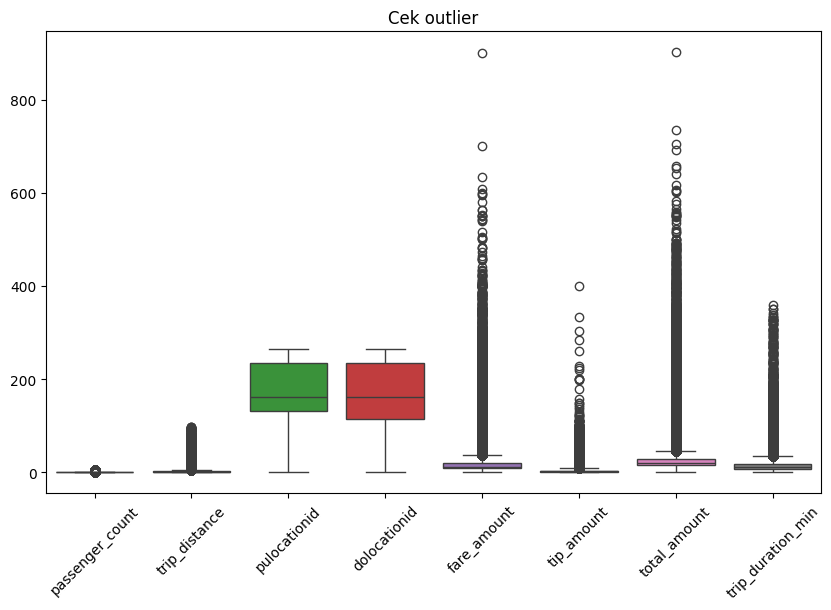

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=yellow_01_clean)
plt.xticks(rotation=45)
plt.title("Cek outlier")
plt.show()

In [ ]:
# Menggabung dataframe yellow dan green taxi
yellow_taxi = pd.concat([yellow_01, yellow_02, yellow_03, yellow_04], ignore_index=True)
green_taxi = pd.concat([green_01, green_02, green_03, green_04], ignore_index=True)
yellow_taxi.info()
green_taxi.info()

In [ ]:
green_taxi.tail()

In [ ]:
# load cleaned data ke skema silver
import os
os.makedirs('../../../../../data/silver', exist_ok=True)
yellow_taxi.to_parquet('../../../../../data/silver/yellow_trips', index=False)
green_taxi.to_parquet('../../../../../data/silver/green_trips', index=False)

import duckdb
con = duckdb.connect(database='../../../../../data/silver/nyc_taxi.duckdb', read_only=False)
con.execute("CREATE SCHEMA IF NOT EXISTS silver")
con.execute("CREATE OR REPLACE TABLE silver.yellow_trips AS SELECT * FROM read_parquet('../../../../../data/silver/yellow_trips')")
con.execute("CREATE OR REPLACE TABLE silver.green_trips AS SELECT * FROM read_parquet('../../../../../data/silver/green_trips')")